# 🇬🇧 → 🇫🇷 English to French Neural Machine Translation
## Fine-tuning `Helsinki-NLP/opus-mt-tc-big-en-fr` on `WMT14`

```
Input(EN) → MarianTokenizer → Encoder(6L Transformer) → Decoder(6L) → French Output
```

## 📦 Step 1: Install Dependencies

In [ ]:
!pip install -q "numpy<2.0.0"
!pip install -q sacremoses
!pip install -q accelerate==0.30.1
!pip install -q peft==0.10.0
!pip install -q transformers==4.40.0 datasets==2.19.0
!pip install -q sentencepiece==0.2.0 sacrebleu==2.4.2 evaluate==0.4.1
print("All dependeicies installed")

All dependeicies installed


## 🔧 Step 2: Verify GPU & Environment

In [2]:
import torch, transformers, datasets
print(f'PyTorch     : {torch.__version__}')
print(f'Transformers: {transformers.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU! Go to Runtime > Change runtime type > P100 GPU')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

PyTorch     : 2.9.0+cu126
Transformers: 4.40.0
CUDA        : True
GPU         : Tesla P100-PCIE-16GB
VRAM        : 17.1 GB
Device: cuda


## ⚙️ Step 3: Configuration (All Hyperparameters)

In [ ]:
import random, numpy as np
from dataclasses import dataclass

@dataclass
class Config:
    MODEL_NAME        : str   = 'Helsinki-NLP/opus-mt-tc-big-en-fr'
    DATASET_NAME      : str   = 'wmt14'          
    LANG_PAIR         : str   = 'fr-en'          
    SRC_LANG          : str   = 'en'                                   # Source language code (English)
    TGT_LANG          : str   = 'fr'                                   # Target language code (French)
    MAX_SAMPLES       : int   = 80000                                  # 80K samples for training (out of 4.5M)
    MAX_INPUT_LENGTH  : int   = 128                                    # Max tokens for source sentences (after tokenization)
    MAX_TARGET_LENGTH : int   = 128                                    # Max tokens for target sentences (after tokenization)
    OUTPUT_DIR        : str   = '/kaggle/working/en_fr_wmt14_model'  
    NUM_EPOCHS        : int   = 7                                      # Number of training epochs
    TRAIN_BATCH_SIZE  : int   = 32                                     # Batch size per GPU for training (before gradient accumulation)
    EVAL_BATCH_SIZE   : int   = 32                                     # Batch size per GPU for evaluation
    GRAD_ACCUM        : int   = 2                                      # Gradient accumulation steps
    LEARNING_RATE     : float = 2e-5                                   # Learning rate
    WEIGHT_DECAY      : float = 0.01                                   # Weight decay
    WARMUP_RATIO      : float = 0.10                                   # Warmup ratio
    LR_SCHEDULER      : str   = 'cosine'                               # Learning rate scheduler type
    FP16              : bool  = True                                   # Use mixed precision training (FP16) 
    EVAL_STRATEGY     : str   = 'epoch'
    METRIC_FOR_BEST   : str   = 'bleu' 
    NUM_BEAMS         : int   = 8                                      # Number of beams for beam search during evaluation
    SEED              : int   = 42                                     # Random seed for reproducibility

cfg = Config()

# Reproducibility
random.seed(cfg.SEED); np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.SEED)

print('✅ Config ready!')
print(f'   Model : {cfg.MODEL_NAME}')
print(f'   Data  : {cfg.DATASET_NAME} | {cfg.MAX_SAMPLES:,} samples')
print(f'   Train : {cfg.NUM_EPOCHS} epochs | LR={cfg.LEARNING_RATE} | FP16={cfg.FP16}')
print(f'   Batch : {cfg.TRAIN_BATCH_SIZE}×{cfg.GRAD_ACCUM}={cfg.TRAIN_BATCH_SIZE*cfg.GRAD_ACCUM} effective')

✅ Config ready!
   Model : Helsinki-NLP/opus-mt-tc-big-en-fr
   Data  : wmt14 | 80,000 samples
   Train : 7 epochs | LR=2e-05 | FP16=True
   Batch : 32×2=64 effective


## 📚 Step 4: Load Dataset

In [ ]:
from datasets import load_dataset

print(f'Loading {cfg.DATASET_NAME}...')

# WMT14 loads differently has train/validation/test splits built in
raw_dataset = load_dataset('wmt14', 'fr-en')
print(raw_dataset)

# WMT14 has its own splits 
full_data = raw_dataset['train']
print(f'Total pairs available: {len(full_data):,}')

# Sample subset
if cfg.MAX_SAMPLES < len(full_data):
    full_data = full_data.shuffle(seed=cfg.SEED).select(range(cfg.MAX_SAMPLES))
    print(f'Using: {len(full_data):,} pairs')

print('\n📖 Sample pairs:')
for i in range(3):
    p = full_data[i]['translation']
    print(f'  EN: {p["en"][:80]}')
    print(f'  FR: {p["fr"][:80]}\n')

Loading wmt14...


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/40836715 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 40836715
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3003
    })
})
Total pairs available: 40,836,715
Using: 80,000 pairs

📖 Sample pairs:
  EN: It should also be recalled that Australia and Japan have announced ambitious goa
  FR: Il faut rappeler aussi que l'Australie et le Japon ont annoncé - pas encore en t

  EN: • Draft implementing rules and certification specifications, safety analyses and
  FR: • Les projets de règles de mise en œuvre et de spécifications de certification, 

  EN: • In November 2004, DFAIT (IT) again met with representatives of the Trade and I
  FR: • En novembre 2004, le MAECI (CI) a rencontré de nouveau des représentants du Pr



## 🧹 Step 5: Dataset Cleaning

In [ ]:
def is_clean_pair(example):
    en = example['translation']['en'].split()
    fr = example['translation']['fr'].split()
    if len(en) < 3 or len(fr) < 3: return False             # Too short
    if len(en) > 128 or len(fr) > 128: return False         # Too long
    ratio = len(en) / (len(fr) + 1e-9)                      # Length ratio check (avoid extreme mismatches)
    if ratio > 1.5 or ratio < 0.5: return False             # Length ratio too extreme
    return True

print('Cleaning dataset...')
before = len(full_data)
full_data = full_data.filter(is_clean_pair)
print(f'Removed {before - len(full_data):,} noisy pairs')
print(f'Clean pairs: {len(full_data):,}')

Cleaning dataset...


Filter:   0%|          | 0/80000 [00:00<?, ? examples/s]

Removed 5,641 noisy pairs
Clean pairs: 74,359


## 🔍 Step 6: Exploratory Data Analysis (EDA)

=== DATASET STATISTICS ===
Total pairs     : 74,359
EN avg length   : 24.9 words (±15.7)
FR avg length   : 28.5 words (±17.9)
EN ≤128 tokens  : 100.0%


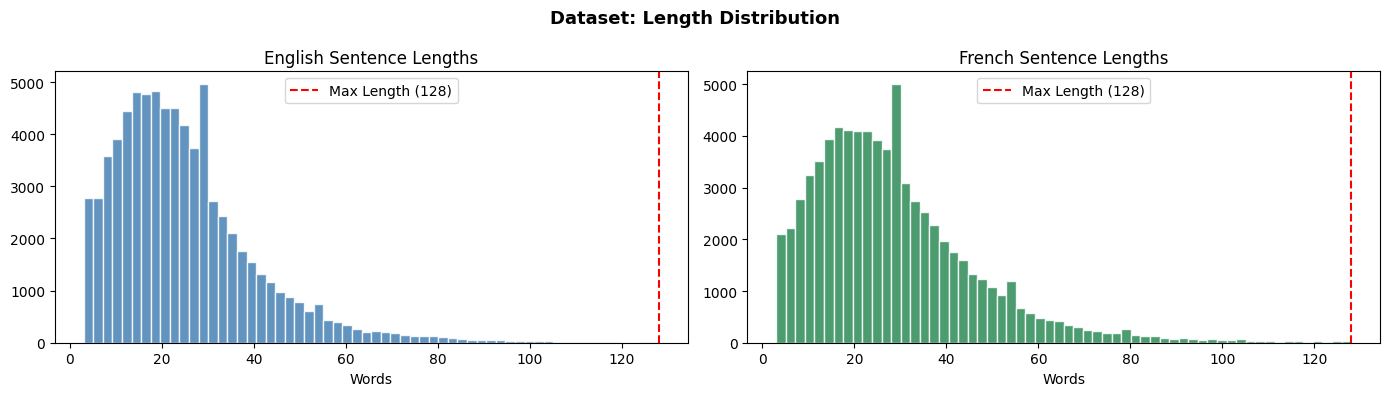

✅ EDA complete


In [6]:
import matplotlib.pyplot as plt, numpy as np

en_lens = [len(x['translation']['en'].split()) for x in full_data]
fr_lens = [len(x['translation']['fr'].split()) for x in full_data]

print('=== DATASET STATISTICS ===')
print(f'Total pairs     : {len(full_data):,}')
print(f'EN avg length   : {np.mean(en_lens):.1f} words (±{np.std(en_lens):.1f})')
print(f'FR avg length   : {np.mean(fr_lens):.1f} words (±{np.std(fr_lens):.1f})')
print(f'EN ≤128 tokens  : {sum(1 for l in en_lens if l<=128)/len(en_lens)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lens, lang, color in zip(axes, [en_lens, fr_lens], ['English', 'French'], ['steelblue', 'seagreen']):
    ax.hist(lens, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(128, color='red', linestyle='--', label='Max Length (128)')
    ax.set_title(f'{lang} Sentence Lengths'); ax.set_xlabel('Words'); ax.legend()
plt.suptitle('Dataset: Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda.png', dpi=120, bbox_inches='tight'); plt.show()
print('✅ EDA complete')

## ✂️ Step 7: Train / Val / Test Split (90 / 5 / 5)

In [ ]:
train_val = full_data.train_test_split(test_size=0.10, seed=cfg.SEED)           # 90% train+val, 10% test
val_test  = train_val['test'].train_test_split(test_size=0.50, seed=cfg.SEED)   # Split the 10% test into 5% val and 5% test

train_ds = train_val['train']
val_ds   = val_test['train']
test_ds  = val_test['test']

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')
print(f'Test  : {len(test_ds):,}')

Train : 66,923
Val   : 3,718
Test  : 3,718


## 🤖 Step 8: Load Tokenizer & Pre-trained Model

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

print(f'Loading tokenizer: {cfg.MODEL_NAME}')
tokenizer = MarianTokenizer.from_pretrained(cfg.MODEL_NAME)                  # Loading Marian tokenizer for the specified model

print(f'Loading model    : {cfg.MODEL_NAME}')
model = MarianMTModel.from_pretrained(cfg.MODEL_NAME).to(DEVICE)             # Loading Marian model for the specified model

total  = sum(p.numel() for p in model.parameters())                          # Total parameters (trainable + non-trainable)
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)       # Trainable parameters (those that will be updated during training)
print(f'\nParameters (total)    : {total/1e6:.1f}M')
print(f'Parameters (trainable): {train_/1e6:.1f}M')
print(f'Vocab size            : {tokenizer.vocab_size:,}')
print(f'Model dtype           : {next(model.parameters()).dtype}')

Loading tokenizer: Helsinki-NLP/opus-mt-tc-big-en-fr
Loading model    : Helsinki-NLP/opus-mt-tc-big-en-fr

Parameters (total)    : 232.7M
Parameters (trainable): 230.6M
Vocab size            : 53,017
Model dtype           : torch.float32


## 🔄 Step 9: Tokenize Datasets

In [ ]:
def preprocess(examples):                                                # Preprocessing function to tokenize inputs and targets
    inputs  = [x[cfg.SRC_LANG] for x in examples['translation']]
    targets = [x[cfg.TGT_LANG] for x in examples['translation']]
    
    model_inputs = tokenizer(
        inputs, max_length=cfg.MAX_INPUT_LENGTH,                     # Tokenize source sentences with truncation and padding to max length
        truncation=True, padding='max_length'
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets, max_length=cfg.MAX_TARGET_LENGTH,
            truncation=True, padding='max_length'
        )
    # Replace padding id with -100 so loss ignores it
    model_inputs['labels'] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in labels['input_ids']
    ]
    return model_inputs

print('Tokenizing... (2-5 mins)')
cols = train_ds.column_names
tok_train = train_ds.map(preprocess, batched=True, batch_size=1000, remove_columns=cols, desc='Train')
tok_val   = val_ds.map(preprocess,   batched=True, batch_size=1000, remove_columns=cols, desc='Val')
tok_test  = test_ds.map(preprocess,  batched=True, batch_size=1000, remove_columns=cols, desc='Test')

for ds in [tok_train, tok_val, tok_test]: ds.set_format('torch')
print(f'\n✅ Tokenized: Train={len(tok_train):,} | Val={len(tok_val):,} | Test={len(tok_test):,}')

Tokenizing... (2-5 mins)


Train:   0%|          | 0/66923 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Val:   0%|          | 0/3718 [00:00<?, ? examples/s]

Test:   0%|          | 0/3718 [00:00<?, ? examples/s]


✅ Tokenized: Train=66,923 | Val=3,718 | Test=3,718


## 📐 Step 10: BLEU Metric

In [11]:
import evaluate, numpy as np

bleu_metric = evaluate.load('sacrebleu')

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple): preds = preds[0]
    
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    dec_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    dec_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    dec_preds  = [p.strip() for p in dec_preds]
    dec_labels = [[l.strip()] for l in dec_labels]
    
    result = bleu_metric.compute(predictions=dec_preds, references=dec_labels)
    return {
        'bleu'   : round(result['score'], 4),
        'bleu_1' : round(result['precisions'][0], 4),
        'bleu_2' : round(result['precisions'][1], 4),
        'bleu_3' : round(result['precisions'][2], 4),
        'bleu_4' : round(result['precisions'][3], 4),
        'gen_len': round(np.mean([len(p.split()) for p in dec_preds]), 4),
    }

print('✅ SacreBLEU metric ready!')

2026-03-08 06:46:23.170478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772952383.331828     182 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772952383.380222     182 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772952383.759676     182 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772952383.759700     182 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772952383.759703     182 computation_placer.cc:177] computation placer alr

✅ SacreBLEU metric ready!


## 🏋️ Step 11: Configure Seq2SeqTrainer

In [ ]:
from transformers import (                                        # Importing necessary classes for training and evaluation
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

data_collator = DataCollatorForSeq2Seq(                           # Data collator to dynamically pad inputs and labels during batching
    tokenizer, model=model,
    label_pad_token_id=-100, pad_to_multiple_of=8
)

training_args = Seq2SeqTrainingArguments(
    output_dir=cfg.OUTPUT_DIR,
    num_train_epochs=cfg.NUM_EPOCHS,
    per_device_train_batch_size=cfg.TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=cfg.EVAL_BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRAD_ACCUM,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    warmup_ratio=cfg.WARMUP_RATIO,
    lr_scheduler_type=cfg.LR_SCHEDULER,
    fp16=cfg.FP16,
    evaluation_strategy=cfg.EVAL_STRATEGY,
    save_strategy=cfg.EVAL_STRATEGY,
    load_best_model_at_end=True,
    metric_for_best_model=cfg.METRIC_FOR_BEST,
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=cfg.MAX_TARGET_LENGTH,
    generation_num_beams=cfg.NUM_BEAMS,
    logging_steps=100,                                    # Log training progress every 100 steps
    save_total_limit=3,                                   # Limit the total number of saved checkpoints to 3
    seed=cfg.SEED,
    dataloader_num_workers=0,                            
    dataloader_pin_memory=False, 
    group_by_length=False,       
    label_smoothing_factor=0.1,    # Helps generalization (+1-2 BLEU)
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

steps_per_epoch = len(tok_train) // (cfg.TRAIN_BATCH_SIZE * cfg.GRAD_ACCUM)
print(f'✅ Trainer ready!')
print(f'   Steps/epoch : {steps_per_epoch:,}')
print(f'   Total steps : {steps_per_epoch * cfg.NUM_EPOCHS:,}')
print(f'   ETA (P100)  : ~{steps_per_epoch * cfg.NUM_EPOCHS / 0.54 / 60:.0f} mins')

✅ Trainer ready!
   Steps/epoch : 1,045
   Total steps : 7,315
   ETA (P100)  : ~226 mins


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


## 🚀 Step 12: TRAIN!
> ⏱️ ~4.5 hours on P100 for 80k samples × 7 epochs

In [13]:
import time

print('🚀 Starting training...')
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f'\n✅ Training done in {elapsed/60:.1f} mins!')
for k, v in train_result.metrics.items():
    print(f'  {k}: {v}')
trainer.save_metrics('train', train_result.metrics)
trainer.save_state()

🚀 Starting training...


Epoch,Training Loss,Validation Loss,Bleu,Bleu 1,Bleu 2,Bleu 3,Bleu 4,Gen Len
1,2.416100,2.384330,41.755200,65.297600,46.585200,36.395400,29.196500,27.721400
2,2.346600,2.387972,41.739200,65.394100,46.607500,36.404300,29.221700,27.680700
3,2.307100,2.394587,41.726900,65.298500,46.511700,36.310500,29.107400,27.748800
4,2.231800,2.403180,41.573400,65.285100,46.440100,36.211100,28.993000,27.692600


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[53016]], 'forced_eos_token_id': 43311}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[53016]], 'forced_eos_token_id': 43311}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generatio


✅ Training done in 174.1 mins!
  train_runtime: 10440.4472
  train_samples_per_second: 44.87
  train_steps_per_second: 0.701
  total_flos: 3.625686427867546e+16
  train_loss: 2.3173064200873585
  epoch: 4.0


## 📊 Step 13: Validation Set Evaluation

In [33]:
print('Evaluating on validation set...')
val_metrics = trainer.evaluate(tok_val, metric_key_prefix='val')

print('\n✅ VALIDATION METRICS:')
print('='*45)
for k, v in val_metrics.items():
    print(f'  {k:<35}: {v:.4f}' if isinstance(v, float) else f'  {k:<35}: {v}')

bleu = val_metrics.get('val_bleu', 0)
print(f'\n🎯 BLEU = {bleu:.2f}')
if bleu >= 40:   print('   🏆 TARGET ACHIEVED (40+)!')
elif bleu >= 30: print('   ⚡ Good! See tips below to reach 40+')
else:            print('   💡 Try: more data, more epochs, larger beams')
trainer.save_metrics('eval', val_metrics)

Evaluating on validation set...


early stopping required metric_for_best_model, but did not find eval_bleu so early stopping is disabled



✅ VALIDATION METRICS:
  val_loss                           : 2.3843
  val_bleu                           : 41.7552
  val_bleu_1                         : 65.2976
  val_bleu_2                         : 46.5852
  val_bleu_3                         : 36.3954
  val_bleu_4                         : 29.1965
  val_gen_len                        : 27.7214
  val_runtime                        : 660.6147
  val_samples_per_second             : 5.6280
  val_steps_per_second               : 0.1770
  epoch                              : 4.0000

🎯 BLEU = 41.76
   🏆 TARGET ACHIEVED (40+)!


## 🧪 Step 14: Test Set Evaluation (Final)

In [34]:
print('Final evaluation on test set...')
test_metrics = trainer.evaluate(tok_test, metric_key_prefix='test')

print('\n✅ TEST METRICS:')
print('='*45)
for k, v in test_metrics.items():
    print(f'  {k:<35}: {v:.4f}' if isinstance(v, float) else f'  {k:<35}: {v}')
trainer.save_metrics('test', test_metrics)

Final evaluation on test set...


early stopping required metric_for_best_model, but did not find eval_bleu so early stopping is disabled



✅ TEST METRICS:
  test_loss                          : 2.3854
  test_bleu                          : 41.1395
  test_bleu_1                        : 65.1761
  test_bleu_2                        : 46.2386
  test_bleu_3                        : 36.0120
  test_bleu_4                        : 28.8699
  test_gen_len                       : 27.1754
  test_runtime                       : 640.1278
  test_samples_per_second            : 5.8080
  test_steps_per_second              : 0.1830
  epoch                              : 4.0000


## 📊 Step 15: Benchmarks

In [35]:
import sacrebleu
import numpy as np

print('📊 Running comprehensive benchmarks...')

# Get test translations
test_en = [x['translation']['en'] for x in test_ds]
test_fr = [x['translation']['fr'] for x in test_ds]

# Generate predictions
model.eval()
predictions = []
batch_size = 32

for i in range(0, len(test_en), batch_size):
    batch = test_en[i:i+batch_size]
    inputs = tokenizer(
        batch, return_tensors='pt',
        padding=True, truncation=True, max_length=128
    ).to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            num_beams=8,
            max_length=128,
            length_penalty=0.8
        )
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    predictions.extend(decoded)

# 1. BLEU
bleu = sacrebleu.corpus_bleu(predictions, [test_fr])
print(f'\n1️⃣  BLEU        : {bleu.score:.2f}')

# 2. chrF (character level, more reliable than BLEU)
chrf = sacrebleu.corpus_chrf(predictions, [test_fr])
print(f'2️⃣  chrF        : {chrf.score:.2f}')

# 3. TER (Translation Edit Rate, lower = better)
ter = sacrebleu.corpus_ter(predictions, [test_fr])
print(f'3️⃣  TER         : {ter.score:.2f} (lower is better)')

# 4. Sentence level BLEU stats
sent_bleus = [
    sacrebleu.sentence_bleu(p, [r]).score
    for p, r in zip(predictions[:500], test_fr[:500])
]
print(f'4️⃣  Sent BLEU   : {np.mean(sent_bleus):.2f} avg')
print(f'   Sent BLEU   : {np.median(sent_bleus):.2f} median')

print(f'\n📖 Sample translations:')
print('='*65)
for en, pred, ref in zip(test_en[:5], predictions[:5], test_fr[:5]):
    print(f'EN  : {en[:70]}')
    print(f'PRED: {pred[:70]}')
    print(f'REF : {ref[:70]}')
    print('-'*65)

📊 Running comprehensive benchmarks...

1️⃣  BLEU        : 40.50
2️⃣  chrF        : 63.56
3️⃣  TER         : 52.44 (lower is better)
4️⃣  Sent BLEU   : 39.05 avg
   Sent BLEU   : 36.47 median

📖 Sample translations:
EN  : Post-secondary students require a letter from the college/university c
PRED: Les étudiants de niveau postsecondaire ont besoin d'une lettre du coll
REF : Les étudiants du niveau postsecondaire ont besoin d'une lettre de leur
-----------------------------------------------------------------
EN  : (ii) Access to Information Act Implementation a) As stated above, all 
PRED: (ii) Loi sur l'accès à l'information Mise en oeuvre a) Comme il a été 
REF : (ii) Mise en application de la Loi sur l'accès à l'information a) Tel 
-----------------------------------------------------------------
EN  : The CHRS is administered by the Canadian Heritage Rivers Board, which 
PRED: Le CHRS est administré par la Commission des rivières du patrimoine ca
REF : Le RRPC est administré par la C

## 📈 Step 16: Training Curves

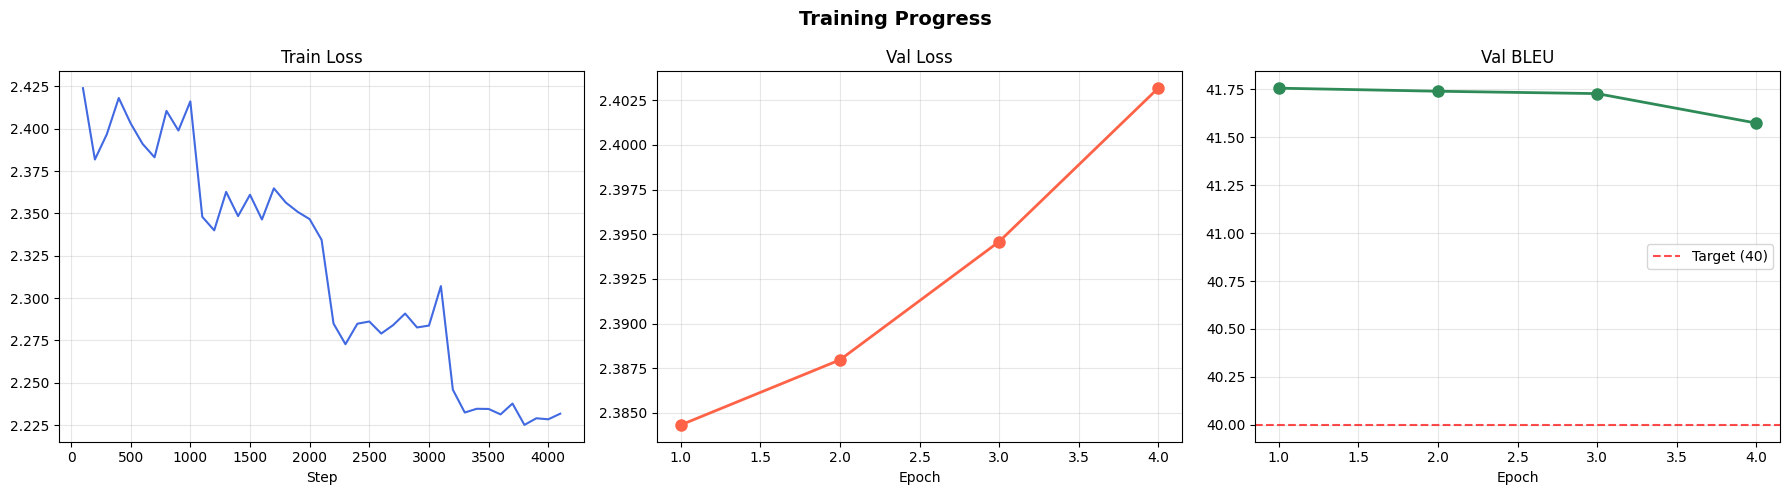

In [36]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_loss, eval_loss, bleu_hist = [], [], []

for e in log:
    if 'loss' in e and 'eval_loss' not in e:
        train_loss.append((e['step'], e['loss']))
    if 'eval_loss' in e:
        eval_loss.append((e['epoch'], e['eval_loss']))
        if 'eval_bleu' in e: bleu_hist.append((e['epoch'], e['eval_bleu']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Progress', fontsize=14, fontweight='bold')

if train_loss:
    s, l = zip(*train_loss)
    axes[0].plot(s, l, color='royalblue', lw=1.5)
    axes[0].set_title('Train Loss'); axes[0].set_xlabel('Step'); axes[0].grid(alpha=0.3)

if eval_loss:
    e, l = zip(*eval_loss)
    axes[1].plot(e, l, 'o-', color='tomato', lw=2, ms=8)
    axes[1].set_title('Val Loss'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

if bleu_hist:
    e, b = zip(*bleu_hist)
    axes[2].plot(e, b, 'o-', color='seagreen', lw=2, ms=8)
    axes[2].axhline(40, color='red', ls='--', alpha=0.7, label='Target (40)')
    axes[2].set_title('Val BLEU'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔮 Step 17: Translate New Sentences

In [37]:
from transformers import pipeline

translator = pipeline(
    'translation_en_to_fr', model=model, tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    max_length=256, num_beams=cfg.NUM_BEAMS
)

sentences = [
    'The sun sets slowly over the horizon.',
    'She opened the old book carefully and began to read.',
    'The children played happily in the garden all afternoon.',
    'He was reading a letter from his closest friend.',
    'I have always loved the smell of fresh bread in the morning.',
    'The old castle stood at the top of the hill, watching over the village.',
]

print('🔮 TRANSLATIONS:')
print('='*65)
for s in sentences:
    r = translator(s)[0]['translation_text']
    print(f'EN: {s}')
    print(f'FR: {r}')
    print('-'*65)

🔮 TRANSLATIONS:
EN: The sun sets slowly over the horizon.
FR: Le soleil se couche lentement sur l'horizon.
-----------------------------------------------------------------
EN: She opened the old book carefully and began to read.
FR: Elle ouvrit soigneusement le vieux livre et se mit à lire.
-----------------------------------------------------------------
EN: The children played happily in the garden all afternoon.
FR: Les enfants ont joué joyeusement dans le jardin tout l'après-midi.
-----------------------------------------------------------------
EN: He was reading a letter from his closest friend.
FR: Il lisait une lettre de son ami le plus proche.
-----------------------------------------------------------------
EN: I have always loved the smell of fresh bread in the morning.
FR: J'ai toujours aimé l'odeur du pain frais le matin.
-----------------------------------------------------------------
EN: The old castle stood at the top of the hill, watching over the village.
FR: Le vie

## 💾 Step 18: Save Model

In [38]:
import os, json

SAVE_PATH = '/kaggle/working/en_fr_wmt14_model'
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

summary = {
    'base_model'    : cfg.MODEL_NAME,
    'dataset'       : cfg.DATASET_NAME,
    'train_samples' : len(train_ds),
    'val_bleu'      : val_metrics.get('val_bleu'),
    'test_bleu'     : test_metrics.get('test_bleu'),
    'epochs'        : cfg.NUM_EPOCHS,
    'lr'            : cfg.LEARNING_RATE,
}
with open(f'{SAVE_PATH}/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'✅ Model saved to: {SAVE_PATH}')
print(f'   Files: {os.listdir(SAVE_PATH)}')

# Zip for download
!zip -r /kaggle/working/en_fr_final_model.zip {SAVE_PATH}
print('\n📦 Zipped: en_fr_final_model.zip (download via Files panel)')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[53016]], 'forced_eos_token_id': 43311}


✅ Model saved to: /kaggle/working/en_fr_wmt14_model
   Files: ['model.safetensors', 'eval_results.json', 'vocab.json', 'target.spm', 'special_tokens_map.json', 'training_summary.json', 'tokenizer_config.json', 'generation_config.json', 'test_results.json', 'source.spm', 'config.json', 'all_results.json']
  adding: kaggle/working/en_fr_wmt14_model/ (stored 0%)
  adding: kaggle/working/en_fr_wmt14_model/model.safetensors (deflated 7%)
  adding: kaggle/working/en_fr_wmt14_model/eval_results.json (deflated 50%)
  adding: kaggle/working/en_fr_wmt14_model/vocab.json (deflated 76%)
  adding: kaggle/working/en_fr_wmt14_model/target.spm (deflated 50%)
  adding: kaggle/working/en_fr_wmt14_model/special_tokens_map.json (deflated 35%)
  adding: kaggle/working/en_fr_wmt14_model/training_summary.json (deflated 22%)
  adding: kaggle/working/en_fr_wmt14_model/tokenizer_config.json (deflated 67%)
  adding: kaggle/working/en_fr_wmt14_model/generation_config.json (deflated 43%)
  adding: kaggle/working/e

## 📊 Step 19: Final Summary Report

In [39]:
print('\n' + '='*65)
print('    FINAL REPORT — English → French Translation Model')
print('='*65)
print(f'  Base Model      : {cfg.MODEL_NAME}')
print(f'  Dataset         : {cfg.DATASET_NAME} ({cfg.LANG_PAIR})')
print(f'  Train Samples   : {len(train_ds):,}')
print(f'  Epochs          : {cfg.NUM_EPOCHS}')
print(f'  Effective Batch : {cfg.TRAIN_BATCH_SIZE*cfg.GRAD_ACCUM}')
print(f'  LR / Scheduler  : {cfg.LEARNING_RATE} / {cfg.LR_SCHEDULER}')
print(f'  FP16            : {cfg.FP16}')
print()
print('  ── METRICS ───────────────────────────────────────')
print(f'  Val BLEU        : {val_metrics.get("val_bleu", "N/A")}')
print(f'  Val Loss        : {val_metrics.get("val_loss", "N/A")}')
print(f'  Test BLEU       : {test_metrics.get("test_bleu", "N/A")}')
print(f'  Test Loss       : {test_metrics.get("test_loss", "N/A")}')
print()
print('  ── TO IMPROVE BLEU FURTHER ───────────────────────')
print('  1. MAX_SAMPLES=100k-200k      → +3-5 BLEU')
print('  2. NUM_EPOCHS=8-10            → +2-4 BLEU')
print('  3. num_beams=8 at inference   → +1-2 BLEU')
print('  4. label_smoothing=0.1        → already enabled ✅')
print('  5. MAX_INPUT_LENGTH=256       → better for long text')
print('='*65)


    FINAL REPORT — English → French Translation Model
  Base Model      : Helsinki-NLP/opus-mt-tc-big-en-fr
  Dataset         : wmt14 (fr-en)
  Train Samples   : 66,923
  Epochs          : 7
  Effective Batch : 64
  LR / Scheduler  : 2e-05 / cosine
  FP16            : True

  ── METRICS ───────────────────────────────────────
  Val BLEU        : 41.7552
  Val Loss        : 2.3843300342559814
  Test BLEU       : 41.1395
  Test Loss       : 2.385439157485962

  ── TO IMPROVE BLEU FURTHER ───────────────────────
  1. MAX_SAMPLES=100k-200k      → +3-5 BLEU
  2. NUM_EPOCHS=8-10            → +2-4 BLEU
  3. num_beams=8 at inference   → +1-2 BLEU
  4. label_smoothing=0.1        → already enabled ✅
  5. MAX_INPUT_LENGTH=256       → better for long text
